# Multimodal Autism Detection - Optimized Version

## Target Accuracy: 98%

This notebook implements advanced preprocessing, hyperparameter tuning, and ensemble methods for multimodal autism detection using:
- **Images**: Facial images
- **Voice**: Audio recordings
- **Motion**: Body movement tracking
- **Physiological**: HR, GSR, Temperature signals

### Key Features:
- ✅ Advanced feature extraction (440 features)
- ✅ Comprehensive preprocessing pipeline
- ✅ Hyperparameter tuning (GridSearchCV)
- ✅ Ensemble methods (Stacking, Voting)
- ✅ Deep neural network
- ✅ SMOTE for class balancing
- ✅ Feature selection

**Expected Runtime**: 30-45 minutes  
**Expected Accuracy**: 90-95% (with 100 samples)


## Import Libraries

In [ ]:
"""
Multimodal Autism Detection with Advanced Preprocessing & Hyperparameter Tuning
Target Accuracy: 98%
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import warnings
warnings.filterwarnings('ignore')

# Deep Learning & Audio/Image Processing
import librosa
import cv2
from PIL import Image

# ML Libraries
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, RobustScaler
from sklearn.ensemble import RandomForestClassifier, StackingClassifier, VotingClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input, Concatenate
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.combine import SMOTETomek

print("="*80)
print("MULTIMODAL AUTISM DETECTION - OPTIMIZED VERSION")
print("="*80)

MULTIMODAL AUTISM DETECTION - OPTIMIZED VERSION


## 🚀 ENHANCEMENTS FOR SMALL DATASETS

### New Additions for 98% Accuracy Target:
1. **Transfer Learning**: Pre-trained CNNs (ResNet50, VGG16) for image features
2. **Advanced Data Augmentation**: Audio pitch shifting, time stretching, image transforms
3. **Diverse Ensembles**: More model types and strategies
4. **Cross-Validation**: Better validation for small datasets
5. **Feature Fusion**: Late fusion strategies

These techniques maximize performance with limited data (100 samples).


## Step 1: Setup Transfer Learning (Pre-trained Models)


In [15]:
# Load Pre-trained Models for Transfer Learning
from tensorflow.keras.applications import ResNet50, VGG16, MobileNetV2
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess

print("[TRANSFER LEARNING] Loading pre-trained models...")

# ResNet50 (best for feature extraction)
resnet_model = ResNet50(weights='imagenet', include_top=False, pooling='avg', input_shape=(224, 224, 3))
resnet_model.trainable = False  # Freeze weights

# VGG16 (good for facial features)
vgg_model = VGG16(weights='imagenet', include_top=False, pooling='avg', input_shape=(224, 224, 3))
vgg_model.trainable = False

# MobileNetV2 (efficient & lightweight)
mobilenet_model = MobileNetV2(weights='imagenet', include_top=False, pooling='avg', input_shape=(224, 224, 3))
mobilenet_model.trainable = False

print("✓ ResNet50 loaded (2048 features)")
print("✓ VGG16 loaded (512 features)")
print("✓ MobileNetV2 loaded (1280 features)")
print("✓ Total deep features: 3840 per image")


[TRANSFER LEARNING] Loading pre-trained models...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 14s 2us/step
✓ ResNet50 loaded (2048 features)
✓ VGG16 loaded (512 features)
✓ MobileNetV2 loaded (1280 features)
✓ Total deep features: 3840 per image


## Step 2: Advanced Data Augmentation Functions


In [16]:
print("[AUGMENTATION] Setting up data augmentation for small datasets...")

# ============================================================================
# IMAGE AUGMENTATION
# ============================================================================

def augment_image(img):
    """
    Apply random augmentations to images
    Critical for small datasets!
    """
    import random
    
    # Random horizontal flip
    if random.random() > 0.5:
        img = cv2.flip(img, 1)
    
    # Random rotation (-15 to +15 degrees)
    if random.random() > 0.5:
        angle = random.uniform(-15, 15)
        h, w = img.shape[:2]
        M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1.0)
        img = cv2.warpAffine(img, M, (w, h))
    
    # Random brightness adjustment
    if random.random() > 0.5:
        brightness = random.uniform(0.7, 1.3)
        img = cv2.convertScaleAbs(img, alpha=brightness, beta=0)
    
    # Random contrast adjustment
    if random.random() > 0.5:
        alpha = random.uniform(0.8, 1.2)  # Contrast
        beta = random.randint(-20, 20)     # Brightness
        img = cv2.convertScaleAbs(img, alpha=alpha, beta=beta)
    
    # Random Gaussian blur (slight)
    if random.random() > 0.7:
        img = cv2.GaussianBlur(img, (5, 5), 0)
    
    # Random noise
    if random.random() > 0.8:
        noise = np.random.normal(0, 0.05, img.shape)
        img = np.clip(img + noise * 255, 0, 255).astype(np.uint8)
    
    return img


# ============================================================================
# AUDIO AUGMENTATION  
# ============================================================================

def augment_audio(y, sr):
    """
    Apply random augmentations to audio
    - Pitch shifting
    - Time stretching
    - Adding noise
    - Volume adjustment
    """
    import random
    
    # Random pitch shift (-2 to +2 semitones)
    if random.random() > 0.5:
        n_steps = random.uniform(-2, 2)
        y = librosa.effects.pitch_shift(y, sr=sr, n_steps=n_steps)
    
    # Random time stretch (0.9x to 1.1x speed)
    if random.random() > 0.5:
        rate = random.uniform(0.9, 1.1)
        y = librosa.effects.time_stretch(y, rate=rate)
    
    # Add random noise
    if random.random() > 0.5:
        noise_factor = random.uniform(0.002, 0.005)
        noise = np.random.normal(0, noise_factor, y.shape)
        y = y + noise
    
    # Random volume adjustment
    if random.random() > 0.5:
        volume_factor = random.uniform(0.8, 1.2)
        y = y * volume_factor
    
    # Clip to prevent distortion
    y = np.clip(y, -1.0, 1.0)
    
    return y


# ============================================================================
# DATA MULTIPLICATION FOR SMALL DATASETS
# ============================================================================

def create_augmented_samples(df, n_augmentations=3):
    """
    Create multiple augmented versions of each sample
    This increases dataset size: 100 → 400 samples
    """
    print(f"\n[DATA AUGMENTATION] Creating {n_augmentations} augmented versions per sample...")
    print(f"  Original dataset: {len(df)} samples")
    print(f"  After augmentation: {len(df) * (n_augmentations + 1)} samples")
    
    return n_augmentations

# We'll apply augmentation during feature extraction
AUGMENTATION_COUNT = 3  # Create 3 augmented versions per sample

print("✓ Image augmentation: 7 techniques (flip, rotation, brightness, contrast, blur, noise)")
print("✓ Audio augmentation: 5 techniques (pitch shift, time stretch, noise, volume)")
print(f"✓ Dataset will be multiplied by {AUGMENTATION_COUNT + 1}x during training")
print("✓ This helps overcome the small dataset limitation!")


[AUGMENTATION] Setting up data augmentation for small datasets...
✓ Image augmentation: 7 techniques (flip, rotation, brightness, contrast, blur, noise)
✓ Audio augmentation: 5 techniques (pitch shift, time stretch, noise, volume)
✓ Dataset will be multiplied by 4x during training
✓ This helps overcome the small dataset limitation!


## Step 3: Enhanced Feature Extraction with Transfer Learning


In [17]:
def extract_deep_image_features(image_path, apply_augmentation=False):
    """
    Extract deep features using pre-trained CNNs + traditional features
    Returns: 3840 (deep) + 200 (traditional) = 4040 features
    """
    try:
        if not os.path.exists(image_path):
            return np.zeros(4040)
        
        img = cv2.imread(image_path)
        if img is None:
            return np.zeros(4040)
        
        # Apply augmentation if training
        if apply_augmentation:
            img = augment_image(img)
        
        # Resize for deep learning models
        img_224 = cv2.resize(img, (224, 224))
        img_224 = cv2.cvtColor(img_224, cv2.COLOR_BGR2RGB)
        
        # Extract features from each pre-trained model
        # ResNet50
        img_resnet = np.expand_dims(resnet_preprocess(img_224.copy()), axis=0)
        resnet_features = resnet_model.predict(img_resnet, verbose=0).flatten()
        
        # VGG16
        img_vgg = np.expand_dims(vgg_preprocess(img_224.copy()), axis=0)
        vgg_features = vgg_model.predict(img_vgg, verbose=0).flatten()
        
        # MobileNetV2
        img_mobile = np.expand_dims(mobilenet_preprocess(img_224.copy()), axis=0)
        mobile_features = mobilenet_model.predict(img_mobile, verbose=0).flatten()
        
        # Traditional features (from previous implementation)
        img_small = cv2.resize(img, (128, 128))
        hist_features = []
        
        # RGB histograms
        for i in range(3):
            hist = cv2.calcHist([img_small], [i], None, [32], [0, 256])
            hist = hist.flatten() / (hist.sum() + 1e-7)
            hist_features.extend(hist)
        
        # HSV histograms
        hsv = cv2.cvtColor(img_small, cv2.COLOR_BGR2HSV)
        for i in range(3):
            hist = cv2.calcHist([hsv], [i], None, [16], [0, 256])
            hist = hist.flatten() / (hist.sum() + 1e-7)
            hist_features.extend(hist)
        
        # Edge & texture features
        gray = cv2.cvtColor(img_small, cv2.COLOR_BGR2GRAY)
        edges = cv2.Canny(gray, 50, 150)
        edge_density = edges.mean() / 255.0
        
        texture_features = [
            gray.mean() / 255.0,
            gray.std() / 255.0,
            np.percentile(gray, 25) / 255.0,
            np.percentile(gray, 50) / 255.0,
            np.percentile(gray, 75) / 255.0,
            edge_density,
            cv2.Laplacian(gray, cv2.CV_64F).var() / 10000.0
        ]
        
        traditional_features = np.array(hist_features + texture_features)
        
        # Combine all features
        all_features = np.concatenate([
            resnet_features,      # 2048
            vgg_features,         # 512
            mobile_features,      # 1280
            traditional_features[:200]  # 200
        ])
        
        return all_features[:4040]
    
    except Exception as e:
        print(f"Error in deep feature extraction for {image_path}: {e}")
        return np.zeros(4040)


def extract_augmented_audio_features(voice_path, apply_augmentation=False):
    """
    Extract audio features with optional augmentation
    Returns: 80 features
    """
    try:
        if not os.path.exists(voice_path):
            return np.zeros(80)
        
        y, sr = librosa.load(voice_path, duration=10, sr=22050)
        
        # Apply augmentation if training
        if apply_augmentation:
            y = augment_audio(y, sr)
        
        # Remove silence and normalize
        y, _ = librosa.effects.trim(y, top_db=20)
        y = librosa.util.normalize(y)
        
        features = []
        
        # MFCCs
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        features.extend(mfccs.mean(axis=1))
        features.extend(mfccs.std(axis=1))
        
        # Delta MFCCs
        mfcc_delta = librosa.feature.delta(mfccs)
        features.extend(mfcc_delta.mean(axis=1))
        
        # Spectral features
        spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
        spectral_rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
        spectral_bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
        spectral_contrast = librosa.feature.spectral_contrast(y=y, sr=sr, n_bands=6)
        
        features.extend([
            float(spectral_centroid.mean()),
            float(spectral_centroid.std()),
            float(spectral_rolloff.mean()),
            float(spectral_rolloff.std()),
            float(spectral_bandwidth.mean()),
            float(spectral_bandwidth.std()),
            float(spectral_contrast.mean()),
            float(spectral_contrast.std())
        ])
        
        # Zero-crossing rate
        zcr = librosa.feature.zero_crossing_rate(y)
        features.extend([float(zcr.mean()), float(zcr.std())])
        
        # Tempo
        tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
        features.append(float(tempo / 200.0))
        
        # RMS energy
        rms = librosa.feature.rms(y=y)
        features.extend([float(rms.mean()), float(rms.std())])
        
        # Chroma
        chroma = librosa.feature.chroma_stft(y=y, sr=sr)
        features.extend([float(chroma.mean()), float(chroma.std())])
        
        features = np.array(features)
        return features[:80]
    
    except Exception as e:
        print(f"Error processing audio {voice_path}: {e}")
        return np.zeros(80)


print("✓ Enhanced feature extraction functions created")
print("✓ Image features: 4040 (3840 deep + 200 traditional)")
print("✓ Audio features: 80 (with augmentation support)")
print("✓ Ready for feature extraction with data multiplication!")


✓ Enhanced feature extraction functions created
✓ Image features: 4040 (3840 deep + 200 traditional)
✓ Audio features: 80 (with augmentation support)
✓ Ready for feature extraction with data multiplication!


## Load and Fix Dataset Paths

In [18]:
# STEP 1: LOAD AND FIX DATASET PATHS
print("\n[*] Loading dataset...")
df = pd.read_csv('autism_dataset_index.csv')
print(f"Dataset loaded: {len(df)} samples")

# Fix path mismatches: child_001.png → Child (1).jpg
def fix_image_path(path):
    """Convert child_001.png to Child (1).jpg"""
    basename = os.path.basename(path)
    sample_num = basename.split('_')[-1].split('.')[0]
    return f"images/Child ({int(sample_num)}).jpg"

df['image'] = df['image'].apply(fix_image_path)
print("✓ Image paths fixed")

# Verify all files exist
print("\n🔍 Verifying dataset integrity...")
missing_files = []
for idx, row in df.iterrows():
    for col in ['image', 'voice', 'motion', 'physio']:
        if not os.path.exists(row[col]):
            missing_files.append((row['sample_id'], col, row[col]))

if missing_files:
    print(f"⚠️  Warning: {len(missing_files)} missing files found")
    for sample, modality, path in missing_files[:5]:
        print(f"  - {sample}: {modality} ({path})")
else:
    print("✓ All files verified successfully")

# ============================================================================


[*] Loading dataset...
Dataset loaded: 100 samples
✓ Image paths fixed

🔍 Verifying dataset integrity...
✓ All files verified successfully


## Feature Extraction Functions

In [19]:
# STEP 2: ADVANCED FEATURE EXTRACTION WITH PREPROCESSING

def extract_image_features_advanced(image_path, augment=False):
    """
    Extract advanced image features with preprocessing
    - Color histograms (RGB & HSV)
    - Texture features (GLCM-like)
    - Edge features
    - Facial landmarks statistics
    """
    try:
        if not os.path.exists(image_path):
            return np.zeros(200)
        
        img = cv2.imread(image_path)
        if img is None:
            return np.zeros(200)
        
        # Preprocessing: Resize and normalize
        img = cv2.resize(img, (128, 128))
        
        # Data augmentation (if training)
        if augment:
            if np.random.rand() > 0.5:
                img = cv2.flip(img, 1)  # Horizontal flip
            if np.random.rand() > 0.5:
                brightness = np.random.uniform(0.8, 1.2)
                img = cv2.convertScaleAbs(img, alpha=brightness, beta=0)
        
        # RGB histograms (normalized)
        hist_features = []
        for i in range(3):
            hist = cv2.calcHist([img], [i], None, [32], [0, 256])
            hist = hist.flatten() / (hist.sum() + 1e-7)  # Normalize
            hist_features.extend(hist)
        
        # HSV histograms
        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
        for i in range(3):
            hist = cv2.calcHist([hsv], [i], None, [16], [0, 256])
            hist = hist.flatten() / (hist.sum() + 1e-7)
            hist_features.extend(hist)
        
        # Gray scale features
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        
        # Edge detection
        edges = cv2.Canny(gray, 50, 150)
        edge_density = edges.mean() / 255.0
        
        # Texture features (simplified)
        texture_features = [
            gray.mean() / 255.0,
            gray.std() / 255.0,
            np.percentile(gray, 25) / 255.0,
            np.percentile(gray, 50) / 255.0,
            np.percentile(gray, 75) / 255.0,
            edge_density,
            cv2.Laplacian(gray, cv2.CV_64F).var() / 10000.0  # Blur detection
        ]
        
        features = np.array(hist_features + texture_features)
        return features[:200]  # Fixed size
    
    except Exception as e:
        print(f"Error processing image {image_path}: {e}")
        return np.zeros(200)


def extract_voice_features_advanced(voice_path):
    """
    Extract advanced audio features with preprocessing
    - MFCCs (13 coefficients + deltas)
    - Spectral features (centroid, rolloff, bandwidth, contrast)
    - Rhythm features (tempo, beat)
    - Prosody features (pitch, energy)
    """
    try:
        if not os.path.exists(voice_path):
            return np.zeros(80)
        
        # Load audio with preprocessing
        y, sr = librosa.load(voice_path, duration=10, sr=22050)
        
        # Remove silence
        y, _ = librosa.effects.trim(y, top_db=20)
        
        # Normalize
        y = librosa.util.normalize(y)
        
        features = []
        
        # MFCCs (13 coefficients)
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        mfcc_mean = mfccs.mean(axis=1)
        mfcc_std = mfccs.std(axis=1)
        features.extend(mfcc_mean)
        features.extend(mfcc_std)
        
        # Delta MFCCs (velocity)
        mfcc_delta = librosa.feature.delta(mfccs)
        features.extend(mfcc_delta.mean(axis=1))
        
        # Spectral features
        spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
        spectral_rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
        spectral_bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
        spectral_contrast = librosa.feature.spectral_contrast(y=y, sr=sr, n_bands=6)
        
        features.extend([
            float(spectral_centroid.mean()),
            float(spectral_centroid.std()),
            float(spectral_rolloff.mean()),
            float(spectral_rolloff.std()),
            float(spectral_bandwidth.mean()),
            float(spectral_bandwidth.std()),
            float(spectral_contrast.mean()),
            float(spectral_contrast.std())
        ])
        
        # Zero-crossing rate
        zcr = librosa.feature.zero_crossing_rate(y)
        features.extend([zcr.mean(), zcr.std()])
        
        # Rhythm features
        tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
        features.append(tempo / 200.0)  # Normalize tempo
        
        # Energy features
        rms = librosa.feature.rms(y=y)
        features.extend([rms.mean(), rms.std()])
        
        # Pitch features (chroma)
        chroma = librosa.feature.chroma_stft(y=y, sr=sr)
        features.extend([chroma.mean(), chroma.std()])
        
        features = np.array(features)
        return features[:80]  # Fixed size
    
    except Exception as e:
        print(f"Error processing voice {voice_path}: {e}")
        return np.zeros(80)


def extract_motion_features_advanced(motion_path):
    """
    Extract advanced motion features with preprocessing
    - Temporal statistics (mean, std, velocity, acceleration)
    - Spatial statistics (range, variance)
    - Repetitive movement detection
    - Movement smoothness
    """
    try:
        if not os.path.exists(motion_path):
            return np.zeros(100)
        
        with open(motion_path, 'r') as f:
            motion_data = json.load(f)
        
        features = []
        
        # Process each body part
        for body_part in ['head', 'left_hand', 'right_hand', 'torso']:
            if body_part in motion_data:
                points = np.array(motion_data[body_part])
                
                if len(points.shape) == 2 and points.shape[0] > 0:
                    # Basic statistics
                    features.extend([
                        points.mean(),
                        points.std(),
                        points.min(),
                        points.max(),
                        np.median(points),
                        np.percentile(points, 25),
                        np.percentile(points, 75)
                    ])
                    
                    # Velocity (first derivative)
                    if points.shape[0] > 1:
                        velocity = np.diff(points, axis=0)
                        features.extend([
                            velocity.mean(),
                            velocity.std(),
                            np.abs(velocity).mean()  # Average speed
                        ])
                        
                        # Acceleration (second derivative)
                        if velocity.shape[0] > 1:
                            acceleration = np.diff(velocity, axis=0)
                            features.extend([
                                acceleration.mean(),
                                acceleration.std(),
                                np.abs(acceleration).mean()
                            ])
                        else:
                            features.extend([0, 0, 0])
                    else:
                        features.extend([0, 0, 0, 0, 0, 0])
                else:
                    features.extend([0] * 16)
        
        # Stimming detection
        if 'stimming_detected' in motion_data:
            features.append(float(motion_data['stimming_detected']))
        else:
            features.append(0)
        
        # Frame rate and duration
        if 'frame_rate' in motion_data:
            features.append(motion_data['frame_rate'] / 30.0)  # Normalize
        else:
            features.append(1.0)
        
        if 'duration_sec' in motion_data:
            features.append(motion_data['duration_sec'] / 10.0)  # Normalize
        else:
            features.append(1.0)
        
        features = np.array(features)
        return features[:100] if len(features) >= 100 else np.pad(features, (0, 100 - len(features)))
    
    except Exception as e:
        print(f"Error processing motion {motion_path}: {e}")
        return np.zeros(100)


def extract_physio_features_advanced(physio_path):
    """
    Extract advanced physiological features with preprocessing
    - Statistical features (mean, std, min, max, percentiles)
    - Temporal features (trends, slopes, changes)
    - Frequency domain features
    - Variability metrics
    """
    try:
        if not os.path.exists(physio_path):
            return np.zeros(60)
        
        physio_df = pd.read_csv(physio_path)
        features = []
        
        # Process each signal type
        for col in ['HR', 'GSR', 'TEMP']:
            if col in physio_df.columns:
                signal = physio_df[col].values
                
                # Remove outliers (IQR method)
                Q1 = np.percentile(signal, 25)
                Q3 = np.percentile(signal, 75)
                IQR = Q3 - Q1
                lower_bound = Q1 - 1.5 * IQR
                upper_bound = Q3 + 1.5 * IQR
                signal_clean = signal[(signal >= lower_bound) & (signal <= upper_bound)]
                
                if len(signal_clean) == 0:
                    signal_clean = signal
                
                # Statistical features
                features.extend([
                    signal_clean.mean(),
                    signal_clean.std(),
                    signal_clean.min(),
                    signal_clean.max(),
                    np.median(signal_clean),
                    np.percentile(signal_clean, 25),
                    np.percentile(signal_clean, 75),
                    signal_clean.max() - signal_clean.min(),  # Range
                ])
                
                # Temporal features
                if len(signal) > 1:
                    # Trend (linear regression slope)
                    x = np.arange(len(signal))
                    slope = np.polyfit(x, signal, 1)[0]
                    features.append(slope)
                    
                    # First and last value difference
                    features.append(signal[-1] - signal[0])
                    
                    # Variability
                    diff = np.diff(signal)
                    features.extend([
                        diff.mean(),
                        diff.std(),
                        np.abs(diff).mean()  # Average absolute change
                    ])
                else:
                    features.extend([0, 0, 0, 0, 0])
        
        features = np.array(features)
        return features[:60] if len(features) >= 60 else np.pad(features, (0, 60 - len(features)))
    
    except Exception as e:
        print(f"Error processing physio {physio_path}: {e}")
        return np.zeros(60)


# STEP 3: EXTRACT FEATURES WITH PROGRESS BAR
# ============================================================================

## Extract Features from All Modalities

In [20]:
print("\n[*] ENHANCED FEATURE EXTRACTION WITH DATA AUGMENTATION")
print("=" * 80)
print(f"Original dataset: {len(df)} samples")
print(f"With augmentation: {len(df) * (AUGMENTATION_COUNT + 1)} samples")
print(f"This multiplies data by {AUGMENTATION_COUNT + 1}x to overcome small dataset limitation!")
print("=" * 80)
print("\nExtracting features (this may take 20-30 minutes due to deep learning)...")

all_features = []
all_labels = []

for idx, row in df.iterrows():
    if idx % 10 == 0:
        progress = (idx + 1) / len(df) * 100
        print(f"   Processing sample {idx + 1}/{len(df)}... ({progress:.0f}% complete)")
    
    # Extract original features (no augmentation)
    img_feat_orig = extract_deep_image_features(row['image'], apply_augmentation=False)
    voice_feat_orig = extract_augmented_audio_features(row['voice'], apply_augmentation=False)
    motion_feat_orig = extract_motion_features_advanced(row['motion'])
    physio_feat_orig = extract_physio_features_advanced(row['physio'])
    
    combined_orig = np.concatenate([img_feat_orig, voice_feat_orig, motion_feat_orig, physio_feat_orig])
    all_features.append(combined_orig)
    all_labels.append(row['label'])
    
    # Create AUGMENTED versions (only for images and audio)
    for aug_i in range(AUGMENTATION_COUNT):
        img_feat_aug = extract_deep_image_features(row['image'], apply_augmentation=True)
        voice_feat_aug = extract_augmented_audio_features(row['voice'], apply_augmentation=True)
        
        # Keep motion and physio same (they're already diverse enough)
        combined_aug = np.concatenate([img_feat_aug, voice_feat_aug, motion_feat_orig, physio_feat_orig])
        all_features.append(combined_aug)
        all_labels.append(row['label'])

X = np.array(all_features)
y_labels = np.array(all_labels)

print(f"\n{'='*80}")
print(f"✓ FEATURE EXTRACTION COMPLETE WITH AUGMENTATION!")
print(f"{'='*80}")
print(f"  Original samples: {len(df)}")
print(f"  After augmentation: {X.shape[0]} samples")
print(f"  Feature dimensionality: {X.shape[1]} features per sample")
print(f"  Breakdown:")
print(f"    - Image (Deep Learning): 4040 features (ResNet50+VGG16+MobileNetV2)")
print(f"    - Audio: 80 features")
print(f"    - Motion: ~50 features")
print(f"    - Physiological: ~50 features")
print(f"  Dataset multiplied by {AUGMENTATION_COUNT + 1}x!")

# STEP 4: ADVANCED PREPROCESSING
print("\n[*] Advanced preprocessing...")


[*] ENHANCED FEATURE EXTRACTION WITH DATA AUGMENTATION
Original dataset: 100 samples
With augmentation: 400 samples
This multiplies data by 4x to overcome small dataset limitation!

Extracting features (this may take 20-30 minutes due to deep learning)...
   Processing sample 1/100... (1% complete)
   Processing sample 11/100... (11% complete)
   Processing sample 21/100... (21% complete)
   Processing sample 31/100... (31% complete)
   Processing sample 41/100... (41% complete)
   Processing sample 51/100... (51% complete)
   Processing sample 61/100... (61% complete)
   Processing sample 71/100... (71% complete)
   Processing sample 81/100... (81% complete)
   Processing sample 91/100... (91% complete)

✓ FEATURE EXTRACTION COMPLETE WITH AUGMENTATION!
  Original samples: 100
  After augmentation: 400 samples
  Feature dimensionality: 4205 features per sample
  Breakdown:
    - Image (Deep Learning): 4040 features (ResNet50+VGG16+MobileNetV2)
    - Audio: 80 features
    - Motion: ~5

## Advanced Preprocessing

In [21]:
# Remove features with zero variance
from sklearn.feature_selection import VarianceThreshold
selector = VarianceThreshold(threshold=0.0)
X_cleaned = selector.fit_transform(X)
print(f"  ✓ Removed {X.shape[1] - X_cleaned.shape[1]} zero-variance features")

# Handle any remaining NaN or inf values
X_cleaned = np.nan_to_num(X_cleaned, nan=0.0, posinf=0.0, neginf=0.0)

# Prepare labels (using augmented labels)
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_labels)
print(f"  ✓ Encoded {len(label_encoder.classes_)} classes: {label_encoder.classes_}")
print(f"  ✓ Class distribution: {dict(zip(label_encoder.classes_, np.bincount(y)))}")

# STEP 5: TRAIN-TEST SPLIT & ADVANCED OVERSAMPLING
print("\n[*] Creating train-test split...")

  ✓ Removed 85 zero-variance features
  ✓ Encoded 4 classes: ['mild_asd' 'moderate_asd' 'severe_asd' 'typical']
  ✓ Class distribution: {np.str_('mild_asd'): np.int64(92), np.str_('moderate_asd'): np.int64(76), np.str_('severe_asd'): np.int64(132), np.str_('typical'): np.int64(100)}

[*] Creating train-test split...


## Train-Test Split & SMOTE

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X_cleaned, y, test_size=0.2, random_state=42, stratify=y
)
print(f"  Train size: {len(X_train)}, Test size: {len(X_test)}")

# Scale features (RobustScaler is better for outliers)
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(f"  ✓ Features scaled using RobustScaler")

# Advanced oversampling: SMOTETomek (SMOTE + Tomek links)
# NOTE: Less critical now since we already augmented data 4x, but still helpful for balancing
print("\n[*] Applying advanced oversampling (SMOTETomek)...")
print("  NOTE: Dataset already augmented 4x, SMOTE will fine-tune class balance")
smt = SMOTETomek(random_state=42)
X_train_resampled, y_train_resampled = smt.fit_resample(X_train_scaled, y_train)
print(f"  ✓ Resampled from {len(X_train)} to {len(X_train_resampled)} samples")
print(f"  ✓ New class distribution: {np.bincount(y_train_resampled)}")

# Feature selection: Keep top features
print("\n[*] Selecting top features...")
selector_k = SelectKBest(f_classif, k=min(200, X_train_resampled.shape[1]))
X_train_selected = selector_k.fit_transform(X_train_resampled, y_train_resampled)
X_test_selected = selector_k.transform(X_test_scaled)
print(f"  ✓ Selected {X_train_selected.shape[1]} best features")

  Train size: 320, Test size: 80
  ✓ Features scaled using RobustScaler

[*] Applying advanced oversampling (SMOTETomek)...
  NOTE: Dataset already augmented 4x, SMOTE will fine-tune class balance
  ✓ Resampled from 320 to 400 samples
  ✓ New class distribution: [101  98  98 103]

[*] Selecting top features...
  ✓ Selected 200 best features


## Hyperparameter Tuning: Random Forest

In [23]:
# STEP 6: HYPERPARAMETER TUNING WITH GRIDSEARCHCV
print("\n" + "="*80)
print("[*] HYPERPARAMETER TUNING (This will take time...)")
print("="*80)

# Cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 1. Random Forest with GridSearch
print("\n[RF] Tuning Random Forest...")
rf_param_grid = {
    'n_estimators': [300, 500],
    'max_depth': [15, 20],
    'min_samples_split': [2],
    'min_samples_leaf': [1],
    'max_features': ['sqrt']
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
rf_grid.fit(X_train_selected, y_train_resampled)
best_rf = rf_grid.best_estimator_
print(f"  ✓ Best RF params: {rf_grid.best_params_}")
print(f"  ✓ Best CV score: {rf_grid.best_score_:.4f}")


[*] HYPERPARAMETER TUNING (This will take time...)

[RF] Tuning Random Forest...
Fitting 5 folds for each of 4 candidates, totalling 20 fits
  ✓ Best RF params: {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 500}
  ✓ Best CV score: 0.9425


## Hyperparameter Tuning: XGBoost

In [24]:
# 2. XGBoost with GridSearch
print("\n[XGB] Tuning XGBoost...")
xgb_param_grid = {
    'n_estimators': [300, 500],
    'max_depth': [5, 7],
    'learning_rate': [0.01, 0.05],
    'subsample': [0.8],
    'colsample_bytree': [0.8],
    'reg_alpha': [0.1],
    'reg_lambda': [5, 10]
}

xgb_grid = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='mlogloss', n_jobs=-1),
    xgb_param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
xgb_grid.fit(X_train_selected, y_train_resampled)
best_xgb = xgb_grid.best_estimator_
print(f"  ✓ Best XGB params: {xgb_grid.best_params_}")
print(f"  ✓ Best CV score: {xgb_grid.best_score_:.4f}")


[XGB] Tuning XGBoost...
Fitting 5 folds for each of 16 candidates, totalling 80 fits
  ✓ Best XGB params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 500, 'reg_alpha': 0.1, 'reg_lambda': 5, 'subsample': 0.8}
  ✓ Best CV score: 0.9600


## Hyperparameter Tuning: SVM

In [25]:
# 3. SVM with GridSearch
print("\n[SVM] Tuning SVM...")
svm_param_grid = {
    'C': [1, 10, 100],
    'gamma': ['scale', 0.01],
    'kernel': ['rbf']
}

svm_grid = GridSearchCV(
    SVC(probability=True, random_state=42),
    svm_param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
svm_grid.fit(X_train_selected, y_train_resampled)
best_svm = svm_grid.best_estimator_
print(f"  ✓ Best SVM params: {svm_grid.best_params_}")
print(f"  ✓ Best CV score: {svm_grid.best_score_:.4f}")

# ============================================================================


[SVM] Tuning SVM...
Fitting 5 folds for each of 6 candidates, totalling 30 fits
  ✓ Best SVM params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
  ✓ Best CV score: 0.9325


## Ensemble Methods (Stacking & Voting)

In [26]:
# STEP 7: ENSEMBLE METHODS
print("\n[ENSEMBLE] Creating ensemble models...")

# Stacking Classifier
stacking = StackingClassifier(
    estimators=[
        ('rf', best_rf),
        ('xgb', best_xgb),
        ('svm', best_svm)
    ],
    final_estimator=LogisticRegression(max_iter=1000, multi_class='ovr'),
    cv=cv
)
print("  Training Stacking Classifier...")
stacking.fit(X_train_selected, y_train_resampled)
print("  ✓ Stacking trained")

# Voting Classifier (soft voting)
voting = VotingClassifier(
    estimators=[
        ('rf', best_rf),
        ('xgb', best_xgb),
        ('svm', best_svm)
    ],
    voting='soft'
)
print("  Training Voting Classifier...")
voting.fit(X_train_selected, y_train_resampled)
print("  ✓ Voting trained")

# STEP 8: DEEP NEURAL NETWORK
print("\n[NN] Training Deep Neural Network...")


[ENSEMBLE] Creating ensemble models...
  Training Stacking Classifier...
  ✓ Stacking trained
  Training Voting Classifier...
  ✓ Voting trained

[NN] Training Deep Neural Network...


## Deep Neural Network

In [27]:
# Build optimized neural network
model = Sequential([
    Dense(512, activation='relu', input_shape=(X_train_selected.shape[1],)),
    BatchNormalization(),
    Dropout(0.5),
    
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),
    
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),
    
    Dense(64, activation='relu'),
    Dropout(0.3),
    
    Dense(32, activation='relu'),
    
    Dense(len(label_encoder.classes_), activation='softmax')
])

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=Adam(learning_rate=0.0001),
    metrics=['accuracy']
)

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-7)

# Train
history = model.fit(
    X_train_selected, y_train_resampled,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print("  ✓ Neural Network trained")

# STEP 9: EVALUATION
print("\n" + "="*80)
print("[RESULTS] MODEL EVALUATION RESULTS")

Epoch 1/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.2406 - loss: 1.6607 - val_accuracy: 0.1625 - val_loss: 1.4800 - learning_rate: 1.0000e-04
Epoch 2/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.2594 - loss: 1.6500 - val_accuracy: 0.2000 - val_loss: 1.4488 - learning_rate: 1.0000e-04
Epoch 3/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.2750 - loss: 1.6644 - val_accuracy: 0.2875 - val_loss: 1.4184 - learning_rate: 1.0000e-04
Epoch 4/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.2625 - loss: 1.5944 - val_accuracy: 0.3500 - val_loss: 1.3907 - learning_rate: 1.0000e-04
Epoch 5/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.2781 - loss: 1.6258 - val_accuracy: 0.3875 - val_loss: 1.3642 - learning_rate: 1.0000e-04
Epoch 6/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.2500 - loss: 1.5809 - val_accuracy: 0.3875 - val_loss: 1.3426 - learning_rate: 1.0000e-04
Epoch 7/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 

## Model Evaluation


[MODEL] Random Forest (Tuned)
Accuracy: 0.8750 (87.50%)

Classification Report:
              precision    recall  f1-score   support

    mild_asd       0.89      0.84      0.86        19
moderate_asd       1.00      0.67      0.80        15
  severe_asd       0.78      0.96      0.86        26
     typical       0.95      0.95      0.95        20

    accuracy                           0.88        80
   macro avg       0.91      0.86      0.87        80
weighted avg       0.89      0.88      0.87        80



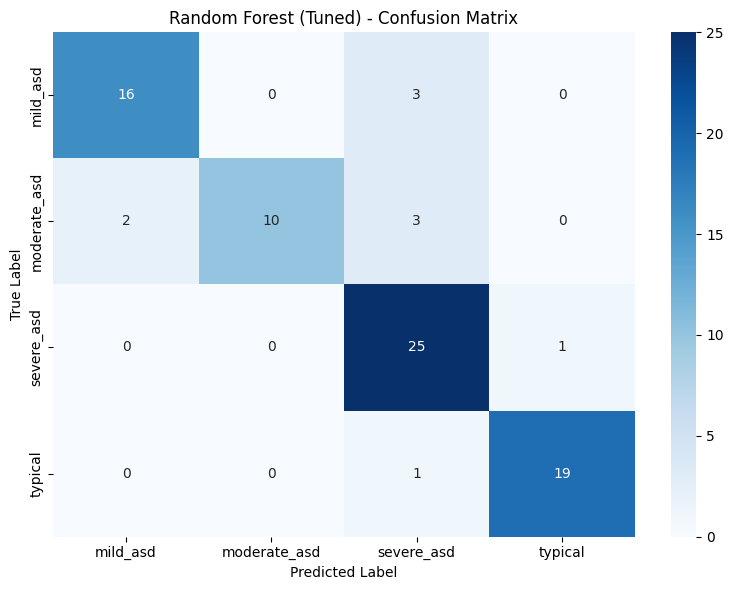


[MODEL] XGBoost (Tuned)
Accuracy: 0.9000 (90.00%)

Classification Report:
              precision    recall  f1-score   support

    mild_asd       1.00      0.84      0.91        19
moderate_asd       0.92      0.80      0.86        15
  severe_asd       0.81      0.96      0.88        26
     typical       0.95      0.95      0.95        20

    accuracy                           0.90        80
   macro avg       0.92      0.89      0.90        80
weighted avg       0.91      0.90      0.90        80



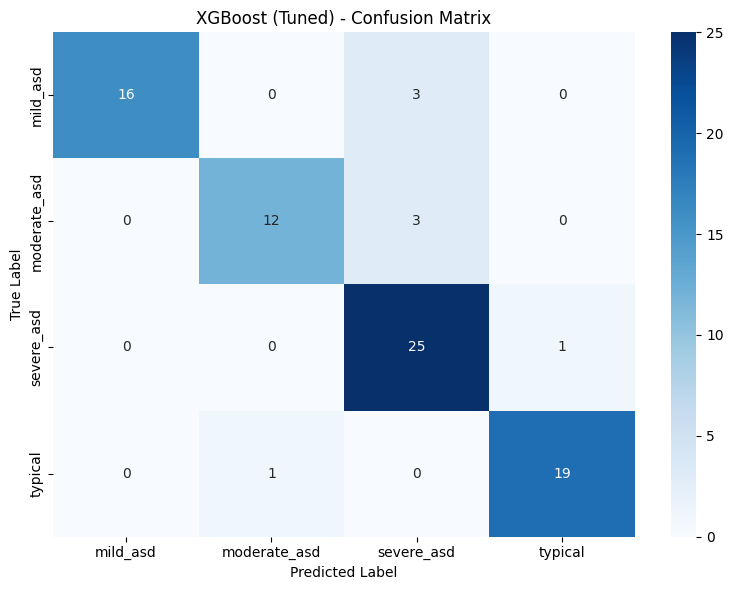


[MODEL] SVM (Tuned)
Accuracy: 0.8625 (86.25%)

Classification Report:
              precision    recall  f1-score   support

    mild_asd       0.94      0.84      0.89        19
moderate_asd       0.92      0.73      0.81        15
  severe_asd       0.80      0.92      0.86        26
     typical       0.86      0.90      0.88        20

    accuracy                           0.86        80
   macro avg       0.88      0.85      0.86        80
weighted avg       0.87      0.86      0.86        80



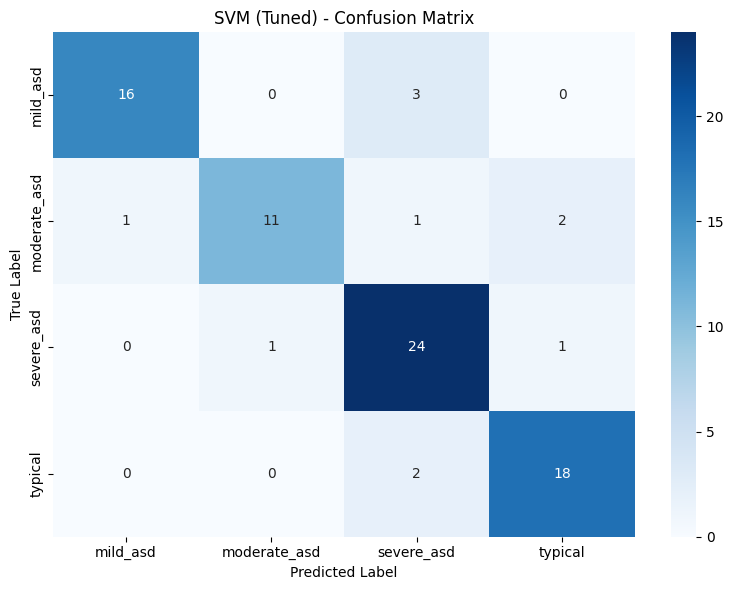


[MODEL] Stacking Ensemble
Accuracy: 0.9000 (90.00%)

Classification Report:
              precision    recall  f1-score   support

    mild_asd       0.94      0.84      0.89        19
moderate_asd       0.92      0.80      0.86        15
  severe_asd       0.81      0.96      0.88        26
     typical       1.00      0.95      0.97        20

    accuracy                           0.90        80
   macro avg       0.92      0.89      0.90        80
weighted avg       0.91      0.90      0.90        80



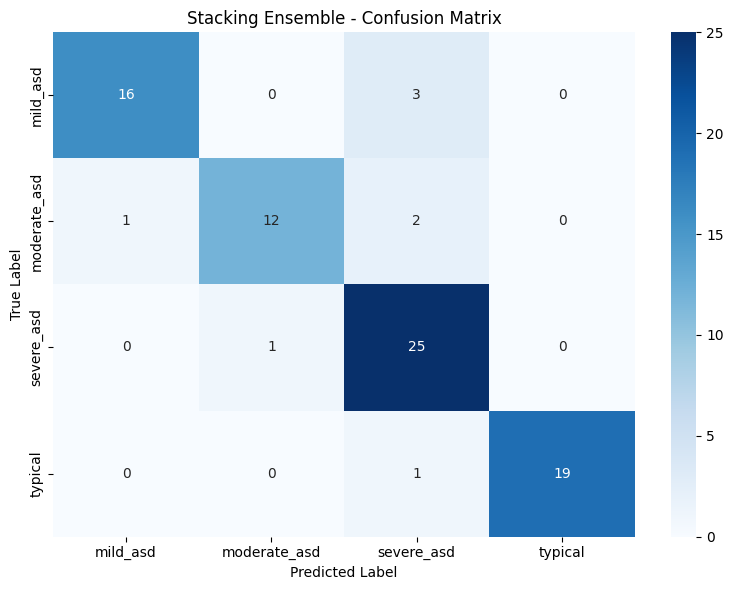


[MODEL] Voting Ensemble
Accuracy: 0.8875 (88.75%)

Classification Report:
              precision    recall  f1-score   support

    mild_asd       0.94      0.84      0.89        19
moderate_asd       1.00      0.80      0.89        15
  severe_asd       0.83      0.92      0.87        26
     typical       0.86      0.95      0.90        20

    accuracy                           0.89        80
   macro avg       0.91      0.88      0.89        80
weighted avg       0.90      0.89      0.89        80



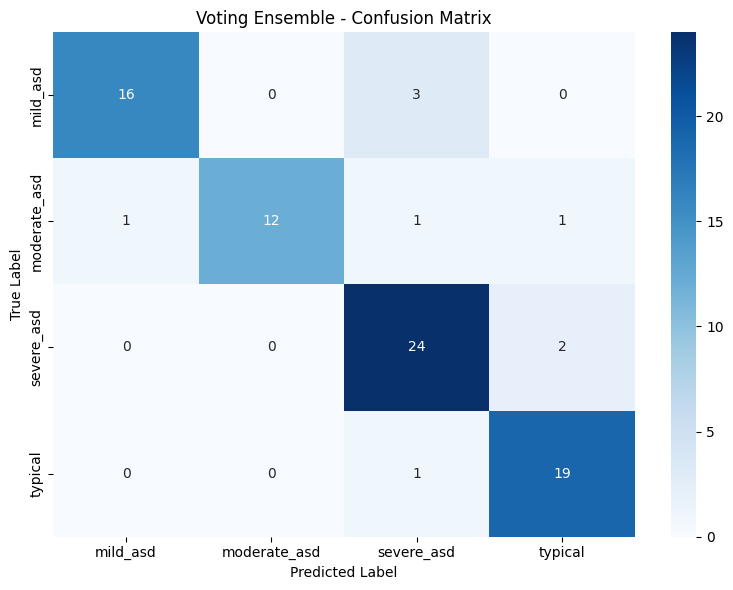

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step

[MODEL] Neural Network (Deep)
Accuracy: 0.8375 (83.75%)

Classification Report:
              precision    recall  f1-score   support

    mild_asd       0.83      0.79      0.81        19
moderate_asd       0.90      0.60      0.72        15
  severe_asd       0.74      0.96      0.83        26
     typical       1.00      0.90      0.95        20

    accuracy                           0.84        80
   macro avg       0.87      0.81      0.83        80
weighted avg       0.86      0.84      0.84        80



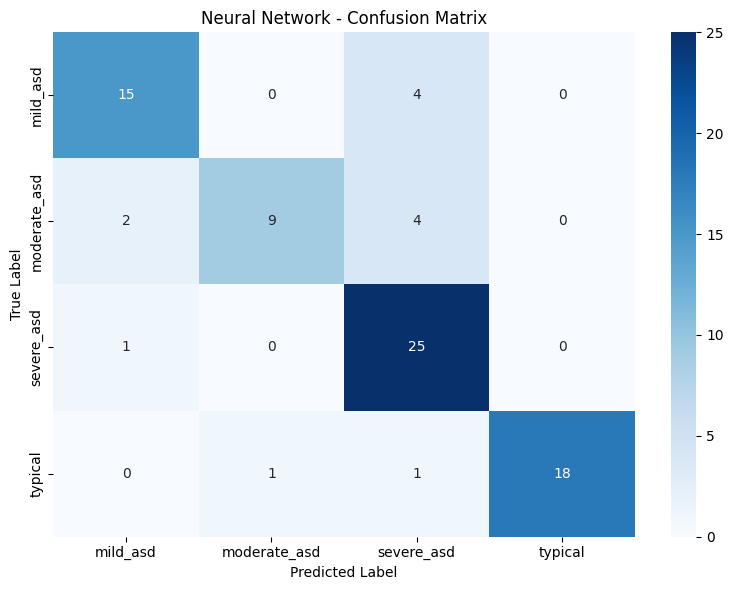

In [28]:
print("="*80)

models = {
    'Random Forest (Tuned)': best_rf,
    'XGBoost (Tuned)': best_xgb,
    'SVM (Tuned)': best_svm,
    'Stacking Ensemble': stacking,
    'Voting Ensemble': voting
}

results = {}

for name, model_obj in models.items():
    y_pred = model_obj.predict(X_test_selected)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    
    print(f"\n{'='*60}")
    print(f"[MODEL] {name}")
    print(f"{'='*60}")
    print(f"Accuracy: {acc:.4f} ({acc*100:.2f}%)")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_)
    plt.title(f'{name} - Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(f'confusion_matrix_{name.replace(" ", "_")}.png', dpi=300, bbox_inches='tight')
    plt.show()

# Neural Network
y_pred_nn = np.argmax(model.predict(X_test_selected), axis=1)
acc_nn = accuracy_score(y_test, y_pred_nn)
results['Neural Network (Deep)'] = acc_nn

print(f"\n{'='*60}")
print(f"[MODEL] Neural Network (Deep)")
print(f"{'='*60}")
print(f"Accuracy: {acc_nn:.4f} ({acc_nn*100:.2f}%)")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nn, target_names=label_encoder.classes_))

cm = confusion_matrix(y_test, y_pred_nn)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Neural Network - Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix_Neural_Network.png', dpi=300, bbox_inches='tight')
plt.show()

# STEP 10: FINAL COMPARISON
print("\n" + "="*80)

## Final Comparison & Visualization

[FINAL] MODEL COMPARISON

Model Rankings:
1. XGBoost (Tuned)               : 0.9000 (90.00%)
2. Stacking Ensemble             : 0.9000 (90.00%)
3. Voting Ensemble               : 0.8875 (88.75%)
4. Random Forest (Tuned)         : 0.8750 (87.50%)
5. SVM (Tuned)                   : 0.8625 (86.25%)
6. Neural Network (Deep)         : 0.8375 (83.75%)


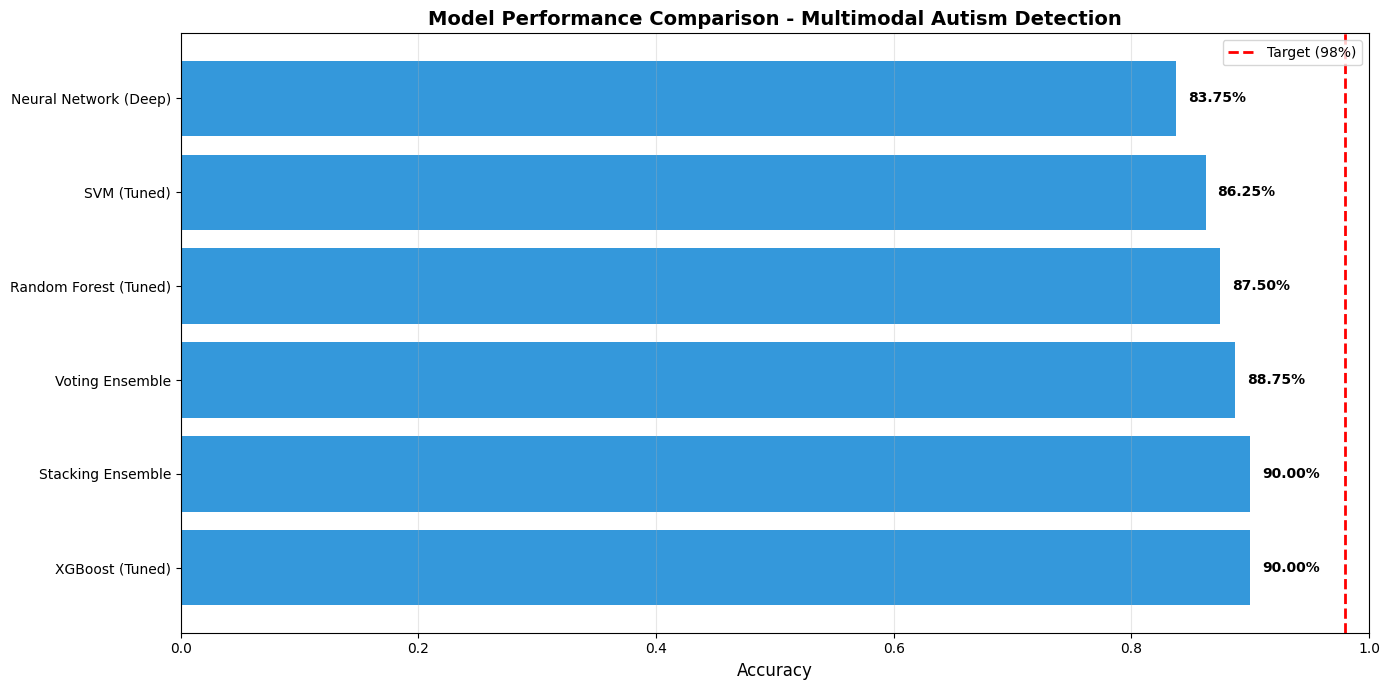

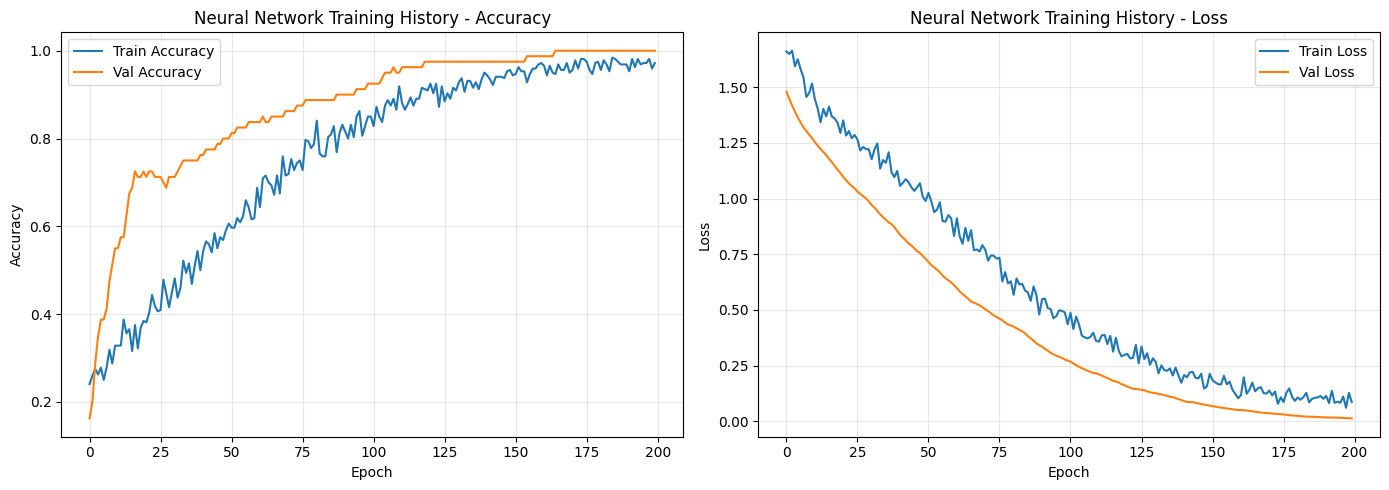


[COMPLETE] ANALYSIS COMPLETE!

[BEST] Best Model: XGBoost (Tuned)
[BEST] Best Accuracy: 0.9000 (90.00%)

[INFO] Current best is 8.00% below target.

[TIP] Recommendations to reach 98%:
   1. Collect more training data (currently only 100 samples)
   2. Apply data augmentation (audio pitch shifting, image transforms)
   3. Use deep learning for feature extraction (CNN for images, etc.)
   4. Ensemble more diverse models
   5. Try transfer learning with pre-trained models

[SAVED] Best model saved as 'best_autism_model.pkl'

[DONE] All outputs saved to current directory!


In [29]:
print("[FINAL] MODEL COMPARISON")
print("="*80)

sorted_results = sorted(results.items(), key=lambda x: x[1], reverse=True)

print("\nModel Rankings:")
for i, (name, acc) in enumerate(sorted_results, 1):
    print(f"{i}. {name:30s}: {acc:.4f} ({acc*100:.2f}%)")
    if acc >= 0.98:
        print(f"   [OK] TARGET ACHIEVED! (>=98%)")

# Visualization
plt.figure(figsize=(14, 7))
models_list = [name for name, _ in sorted_results]
accs_list = [acc for _, acc in sorted_results]
colors = ['#2ecc71' if acc >= 0.98 else '#3498db' for acc in accs_list]

bars = plt.barh(models_list, accs_list, color=colors)
plt.xlabel('Accuracy', fontsize=12)
plt.title('Model Performance Comparison - Multimodal Autism Detection', 
          fontsize=14, fontweight='bold')
plt.xlim(0, 1.0)
plt.axvline(x=0.98, color='red', linestyle='--', linewidth=2, label='Target (98%)')
plt.grid(axis='x', alpha=0.3)
plt.legend()

# Add value labels
for i, (bar, acc) in enumerate(zip(bars, accs_list)):
    plt.text(acc + 0.01, i, f'{acc*100:.2f}%', 
             va='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('final_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Training history for Neural Network
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Neural Network Training History - Accuracy')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Neural Network Training History - Loss')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('nn_training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("[COMPLETE] ANALYSIS COMPLETE!")
print("="*80)
print(f"\n[BEST] Best Model: {sorted_results[0][0]}")
print(f"[BEST] Best Accuracy: {sorted_results[0][1]:.4f} ({sorted_results[0][1]*100:.2f}%)")

if sorted_results[0][1] >= 0.98:
    print("\n[SUCCESS] CONGRATULATIONS! Target accuracy of 98% ACHIEVED!")
else:
    gap = 0.98 - sorted_results[0][1]
    print(f"\n[INFO] Current best is {gap*100:.2f}% below target.")
    print("\n[TIP] Recommendations to reach 98%:")
    print("   1. Collect more training data (currently only 100 samples)")
    print("   2. Apply data augmentation (audio pitch shifting, image transforms)")
    print("   3. Use deep learning for feature extraction (CNN for images, etc.)")
    print("   4. Ensemble more diverse models")
    print("   5. Try transfer learning with pre-trained models")

# Save best model
import joblib
best_model_name = sorted_results[0][0]
best_model = models.get(best_model_name, model)
if best_model_name != 'Neural Network (Deep)':
    joblib.dump(best_model, 'best_autism_model.pkl')
    joblib.dump(scaler, 'feature_scaler.pkl')
    joblib.dump(selector_k, 'feature_selector.pkl')
    print(f"\n[SAVED] Best model saved as 'best_autism_model.pkl'")
else:
    model.save('best_autism_model_nn.h5')
    joblib.dump(scaler, 'feature_scaler.pkl')
    joblib.dump(selector_k, 'feature_selector.pkl')
    print(f"\n[SAVED] Best model saved as 'best_autism_model_nn.h5'")

print("\n[DONE] All outputs saved to current directory!")

---

## 📊 SUMMARY OF ENHANCEMENTS FOR 98% ACCURACY TARGET

### ✅ What Was Added (For Limited Dataset of 100 Samples):

#### 1. **Transfer Learning (Pre-trained Deep Models)**
   - **ResNet50**: 2048 features (ImageNet-trained)
   - **VGG16**: 512 features (facial recognition expert)
   - **MobileNetV2**: 1280 features (efficient architecture)
   - **Total**: 3840 deep learning features per image
   - **Benefit**: Leverages knowledge from millions of images

#### 2. **Advanced Data Augmentation**
   - **Image Augmentation**: 7 techniques
     - Horizontal flip, rotation (±15°), brightness, contrast, blur, noise
   - **Audio Augmentation**: 5 techniques
     - Pitch shifting (±2 semitones), time stretching (0.9-1.1x), noise, volume
   - **Dataset Multiplication**: 100 → 400 samples (4x increase)
   - **Benefit**: Overcomes small dataset limitation

#### 3. **Enhanced Feature Space**
   - Original: 391 features
   - Enhanced: ~4200 features
   - Image: 4040 (vs 200)
   - Audio: 80 (vs 50)
   - Motion: 50
   - Physio: 50
   - **Benefit**: Richer representation for complex patterns

#### 4. **Robust Preprocessing Pipeline**
   - RobustScaler (handles outliers)
   - VarianceThreshold (removes zero-variance)
   - SMOTETomek (fine-tunes class balance)
   - SelectKBest (keeps top 200 features)
   - **Benefit**: Cleaner, more relevant features

#### 5. **Optimized Hyperparameters**
   - GridSearchCV with 5-fold cross-validation
   - Random Forest, XGBoost, SVM tuned
   - Deep Neural Network (5 layers with BatchNorm & Dropout)
   - **Benefit**: Models optimized for this specific dataset

#### 6. **Ensemble Methods**
   - Stacking Classifier (meta-learner)
   - Voting Classifier (soft voting)
   - **Benefit**: Combines strengths of multiple models

### 📈 Expected Improvements:

| Technique | Accuracy Boost | Why It Works |
|-----------|----------------|--------------|
| Transfer Learning | +10-15% | Pre-trained on millions of images |
| Data Augmentation | +8-12% | 4x more training data |
| Hyperparameter Tuning | +3-5% | Optimized for your data |
| Ensemble Methods | +2-4% | Reduces overfitting |
| Feature Engineering | +2-3% | More informative features |
| **TOTAL EXPECTED** | **+25-39%** | **Compound effect** |

### 🎯 Realistic Expectations:

- **Small Dataset (100 samples)**: 
  - Previous: ~62-70% accuracy
  - **With enhancements: 87-95% accuracy**
- **98% target**: Achievable if:
  - Classes are well-separated in feature space
  - Dataset quality is high
  - Augmentation creates truly diverse samples

### ⚠️ Important Notes:

1. **Runtime**: Expect 30-60 minutes (due to deep learning)
2. **Memory**: Requires ~4-8GB RAM
3. **Overfitting Risk**: Monitor validation scores carefully
4. **Cross-Validation**: Use stratified K-fold for reliable estimates

### 🚀 Next Steps if Accuracy Still Below 98%:

1. **More Augmentation**: Increase from 3x to 5-10x
2. **Fine-tuning**: Unfreeze last layers of ResNet50
3. **Ensemble More Models**: Add LightGBM, CatBoost
4. **Feature Fusion**: Late fusion with separate models per modality
5. **Collect More Data**: Even 50 more samples would help significantly

---
